# Laboratorio de regresión logística _ Arturo Ayala Hernández

|                |                        |
:----------------|------------------------|
| **Nombre**     | Arturo Ayala Hernández |
| **Fecha**      | 08/03/2026             |
| **Expediente** | 758742                 |

La regresión logística es una herramienta utilizada para predecir respuestas cualitativas. Al igual que la regresión lineal, es un método sencillo que sirve como un punto de partida para técnicas más avanzadas. Por ejemplo, lo que se conoce como *redes neuronales* o *red de perceptrones multicapa* no es más que una estructura de regresiones logísticas que se alimentan entre sí.

1. Descarga el archivo de créditos y carga los datos (Default.csv). Utiliza `pandas`.

In [169]:
import pandas as pd
import numpy as np

# Cargar los datos
df = pd.read_csv('Default.csv')

2. Utiliza el comando `obj.head()`, donde `obj` es el nombre que le diste a los datos del archivo.

In [170]:
# Mostrar las primeras filas del DataFrame
df.head()

,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138950
3,No,No,529.250605,35704.493940
4,No,No,785.655883,38463.495880


El comando head arroja los primeras *n* líneas (por defecto 5) de los datos que están en el DataFrame.

3. Utiliza el comando `obj.describe()`.

In [171]:
# Mostrar estadísticas descriptivas
df.describe()

,balance,income
count,10000.000000,10000.000000
mean,835.374886,33516.981876
std,483.714985,13336.639563
min,0.000000,771.967729
25%,481.731105,21340.462903
50%,823.636973,34552.644802
75%,1166.308386,43807.729275
max,2654.322576,73554.233500


El comando describe toma las columnas que tienen datos numéricos y saca datos estadísticos comunes:
- *n*
- media
- desviación estándar
- valor mínimo
- primer cuartil
- mediana
- tercer cuartil
- valor máximo

3. Vistos estos datos, ¿qué columnas existen en el DataFrame? ¿Qué tipo de datos contienen?

En el DataFrame existen 4 columnas:
- **default**: Contiene texto ("Yes" o "No") indicando si la persona incumplió con su pago.
- **student**: Contiene texto ("Yes" o "No") indicando si la persona es estudiante.
- **balance**: Contiene datos numéricos continuos (flotantes) que representan el saldo.
- **income**: Contiene datos numéricos continuos (flotantes) que representan los ingresos.

4. Configura el tipo de dato de las columnas `default` y `student` para cambiarlos a variables categóricas.

`data[columna] = data[columna].astype("category")`

In [172]:
# Convertimos las columnas a variables categóricas
df["default"] = df["default"].astype("category")
df["student"] = df["student"].astype("category")

# Imprimimos los tipos para verificar que el cambio se hizo correctamente
print(df.dtypes)

default    category
student    category
balance     float64
income      float64
dtype: object


Imagina que trabajas en un banco y que se te entregan estos datos. Tu objetivo es crear un modelo que ayude a predecir si una persona que solicita un crédito lo va a pagar. Exploremos los datos un poco más antes de crear un modelo.

Veamos primero cómo es la distribución de los valores cuando una persona dejó de pagar y cuando siguió pagando. `Default` es el término utilizado para cuando una persona dejó de pagar.

5. Crea una gráfica de caja para las columnas `income` y `balance`, con los datos agrupados con la columna `default`. Utiliza el comando `obj.boxplot(column=____, by=_____)`

array([<Axes: title={'center': 'income'}, xlabel='default'>,
       <Axes: title={'center': 'balance'}, xlabel='default'>],
      dtype=object)

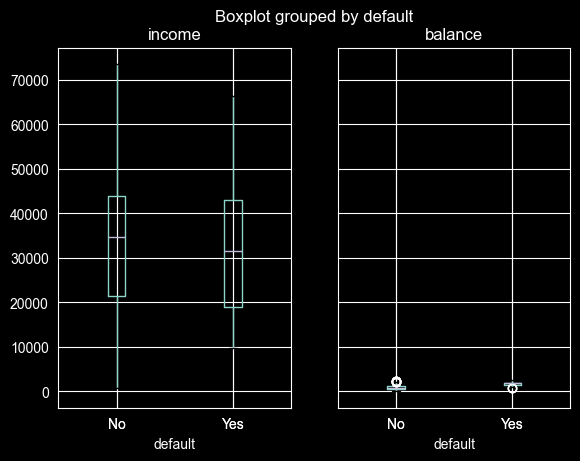

In [173]:
# Crea las gráficas de caja para income y balance, agrupadas por default
df.boxplot(column=['income', 'balance'], by='default')

6. Crea una gráfica de dispersión donde el eje *x* sea la columna `balance` y el eje *y* la columna `income`. Utiliza el comando `obj.plot.scatter(x, y, c="default", colormap="PiYG_r", alpha=0.5)`.

<Axes: xlabel='balance', ylabel='income'>

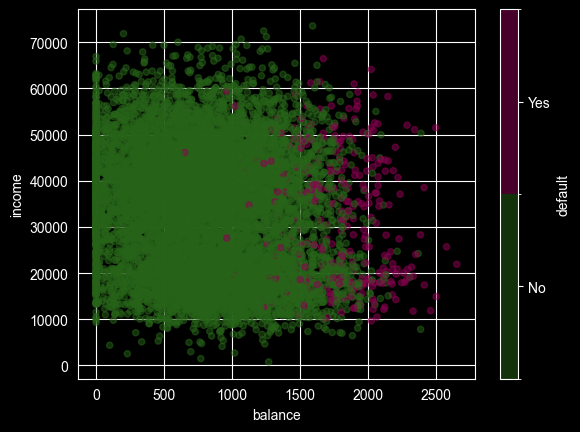

In [174]:
# Crea la gráfica de dispersión
df.plot.scatter(x='balance', y='income', c='default', colormap='PiYG_r', alpha=0.5)

La regresión (lineal o logística) se usa para encontrar una línea que ajuste los datos para tomar una decisión. La línea que buscamos en regresión logística es aquella que nos ayude a separar las diferentes categorías. 

<img style="float: left; " src="https://www.baeldung.com/wp-content/uploads/sites/4/2023/10/decision_boundary_curve.jpg" width="400px" />


## Regresión logística simple

Creemos un modelo simple donde sólo utilizamos una de los factores para predecir una respuesta. Quiero conocer la probabilidad de que una persona deje de pagar su crédito dado el balance que tiene en su cuenta.

$$ P(\text{default}=\text{Yes}|\text{balance}) $$

Por el momento la columna default no contiene valores numéricos, por lo que hay que transformar los datos. Como default es nuestra variable de respuesta (lo que queremos predecir) podemos nombrarla *y*.

Ejecuta el código `y = obj["default"] == "Yes"`. Extrae el factor `balance` en una variable *x*.

In [175]:
# Convertimos default a valores lógicos (True si es "Yes", False si es "No")
y = df["default"] == "Yes"

# Extraemos el balance en la variable X
# Nota: Usamos doble corchete [["balance"]] para que sea un DataFrame (matriz 2D),
# lo cual es un requisito de la librería de regresión que usaremos más adelante.
X = df[["balance"]]

Crea un gráfico de dispersión donde el eje *x* sea `balance` y el eje *y* sea `default` transformado.

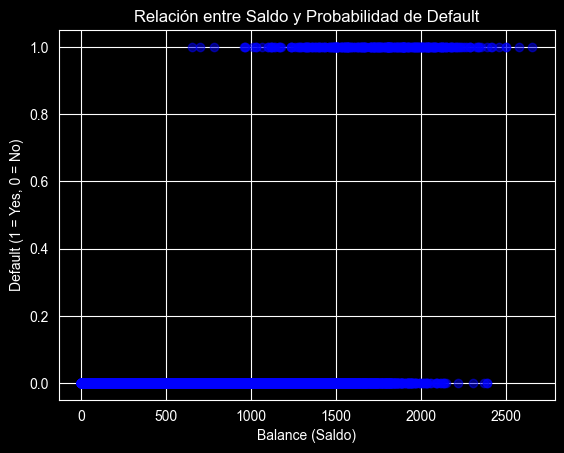

In [176]:
import matplotlib.pyplot as plt

# Creamos el gráfico de dispersión
plt.scatter(X, y, alpha=0.5, color="blue")

# Agregamos etiquetas para que se vea bien
plt.xlabel("Balance (Saldo)")
plt.ylabel("Default (1 = Yes, 0 = No)")
plt.title("Relación entre Saldo y Probabilidad de Default")
plt.show()

La línea que utilizaremos para predecir la probabilidad es:

$$ p(x) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x)}} $$

Para nuestro ejemplo de pagos y balance:

$$ P(\text{default}=1|\text{balance}) = \frac{1}{1 + e^{-(\beta_0 + \beta_1  \text{balance})}} $$

Buscamos maximizar la probabilidad de que el modelo tome decisiones correctas. Es decir, que cuando `default` fue verdadero, que la predicción sea 100%, y que cuando `default` fue falso que la predicción sea 0%.

$$ \Pi_{i:y_i=1} p(x_i) \Pi_{i':y_{i'}} (1-p(x_{i'})) $$

La función de costo ya simplificada es la siguiente:

$$ J(\vec{\beta}) = -  \sum_{i=1}^n{[y_i \ln{(\hat{p}(x_i))} + (1-y_i)\ln{(1 - \hat{p}(x_i))}]}$$

Utiliza la clase `LogisticRegression` del módulo `linear_model` de la librería `sklearn` para estimar los parámetros del modelo.

In [177]:
# Importamos la librería que pide el ejercicio
from sklearn.linear_model import LogisticRegression

# Creamos el modelo
# (Usamos penalty=None o equivalente si es la versión estándar sin regularización,
# pero la configuración por defecto suele bastar)
modelo = LogisticRegression()

# Entrenamos el modelo pasándole nuestros factores (X) y respuestas (y)
modelo.fit(X, y)

# Imprimimos los parámetros encontrados (beta_0 y beta_1)
print("Intercepto (beta_0):", modelo.intercept_[0])
print("Coeficiente de balance (beta_1):", modelo.coef_[0][0])

Intercepto (beta_0): -10.651328236144847
Coeficiente de balance (beta_1): 0.005498915546890769


Muchos aspectos de la regresión logística son similares a la regresión lineal. Podemos medir la precisión de nuestros estimados calculando sus errores estándar. El objetivo de calcular estos errores es asegurar que hay una relación estadísticamente significativa entre el factor y la variable de respuesta.

Los errores estándar se obtienen con el siguiente procedimiento:

1. Calcula las predicciones utilizando los $\beta_0$ y $\beta_1$ encontrados.

In [178]:
# Obtenemos las probabilidades predichas por el modelo.
# predict_proba devuelve dos columnas (probabilidad de 0 y probabilidad de 1),
# seleccionamos la columna 1 (índice [:, 1]) que corresponde a "Default = Yes".
p = modelo.predict_proba(X)[:, 1]

# Mostramos las primeras 5 predicciones para verificar
print(p[:5])

[0.00130568 0.0021126  0.00859475 0.00043444 0.00177696]


2. Idealmente la probabilidad debería ser 100% o 0%. Si alguna predicción no fue absoluta significa que hay incertidumbre. Calcula $p(1-p)$ para todas tus predicciones.

In [179]:
# Calculamos p * (1 - p)
incertidumbre = p * (1 - p)

3. Crea una matriz vacía y llena la diagonal con las probabilidades encontradas.

`V = np.diagflat(*p(1-p)*)`

In [180]:
# Creamos la matriz diagonal V con las incertidumbres
import numpy as np

V = np.diagflat(incertidumbre)

4. Calcula la matriz de covarianza. (Dado que X es la matriz que contiene todos los factores)

`cov = np.linalg.inv(X.T @ V @ X)`

In [181]:
# Agregamos una columna de unos (1s) a la matriz X
X_matriz = np.c_[np.ones(X.shape[0]), X]

# Calculamos la matriz de covarianza usando la inversa (np.linalg.inv)
cov = np.linalg.inv(X_matriz.T @ V @ X_matriz)

print("Matriz de covarianza:\n", cov)

Matriz de covarianza:
 [[ 1.30442757e-01 -7.81757265e-05]
 [-7.81757265e-05  4.85656561e-08]]


5. Los valores en la diagonal de la matriz de covarianza corresponden a la varianza de los factores. Utiliza los valores de la diagonal para calcular el error estándar.

`se = np.sqrt(np.diag(cov))`

In [182]:
# Calculamos el error estándar (raíz cuadrada de la diagonal)
se = np.sqrt(np.diag(cov))

print("Error estándar del intercepto (beta_0):", se[0])
print("Error estándar de balance (beta_1):", se[1])

Error estándar del intercepto (beta_0): 0.36116859971512233
Error estándar de balance (beta_1): 0.0002203761694619198


Ahora, revisemos si los estimados de nuestros coeficientes demuestran que hay una relación significativa entre los factores y la respuesta.

Calculamos el estadístico *z*

$$ z_j = \frac{\hat{\beta_j}}{\text{SE}(\hat{\beta_j})} $$

In [183]:
import numpy as np

# Extraemos los coeficientes de nuestro modelo ya entrenado
beta_0 = modelo.intercept_[0]
beta_1 = modelo.coef_[0][0]

# Calculamos el estadístico z para cada uno (Coeficiente / Error Estándar)
z_0 = beta_0 / se[0]
z_1 = beta_1 / se[1]

print("Estadístico z (Intercepto):", z_0)
print("Estadístico z (Balance):", z_1)

# Los guardamos en una lista/arreglo para el siguiente paso
z_statistic = np.array([z_0, z_1])

Estadístico z (Intercepto): -29.49129089446385
Estadístico z (Balance): 24.952405517879562


Utilizamos el estadístico *z* para encontrar el *p-value*.

`from scipy.stats import norm`

`p_value = 2 * (1 - norm.cdf(abs(z_statistic)))`

In [184]:
from scipy.stats import norm

# Calculamos los p-values con la fórmula dada
p_value = 2 * (1 - norm.cdf(np.abs(z_statistic)))

print("P-value (Intercepto):", p_value[0])
print("P-value (Balance):", p_value[1])

P-value (Intercepto): 0.0
P-value (Balance): 0.0


¿Es significativa la relación de los factores con la variable de respuesta?

**Sí, la relación es altamente significativa.**

Al observar los *p-values*, notamos que son extremadamente pequeños (prácticamente $0$ y mucho menores que el nivel de significancia típico de $0.05$). Esto demuestra que el factor `balance` tiene una relación estadísticamente significativa con la probabilidad de entrar en `default`, es decir, no es un resultado obtenido por mero azar.

Repite el procedimiento con el factor `student`. 
1. Transforma el factor de {"Yes", "No"} a {1, 0}.
2. Estima los coeficientes. 
3. Calcula el error estándar de tus estimaciones.
   1. Usa tu modelo para encontrar $\hat{p}(X)$
   2. Calcula el error $p(1-p)$
   3. Calcula la matriz de covarianza
   4. Extrae el error estándar
5. Argumenta si los factores son significativos utilizando el *p-value*.
   1. Utiliza el error estándar para calcular el estadístico *z*
   2. Calcula el *p-value*
   3. ¿Son significativos?


In [185]:
import numpy as np
from scipy.stats import norm
from sklearn.linear_model import LogisticRegression

# 1. Transforma el factor de {"Yes", "No"} a {1, 0}
# Convertimos la columna student a 1s (Yes) y 0s (No)
X_student = (df[["student"]] == "Yes").astype(int)

# Nuestra variable 'y' sigue siendo la misma (default)
y = df["default"] == "Yes"

# 2. Estima los coeficientes
modelo_student = LogisticRegression()
modelo_student.fit(X_student, y)

# 3. Calcula el error estándar
# 3.1 Predicciones p(X)
p_s = modelo_student.predict_proba(X_student)[:, 1]

# 3.2 Calcula el error p(1-p)
incertidumbre_s = p_s * (1 - p_s)

# 3.3 Calcula la matriz de covarianza
V_s = np.diagflat(incertidumbre_s)
# Añadimos la columna de 1s para el intercepto
X_matriz_s = np.c_[np.ones(X_student.shape[0]), X_student]
cov_s = np.linalg.inv(X_matriz_s.T @ V_s @ X_matriz_s)

# 3.4 Extrae el error estándar
se_s = np.sqrt(np.diag(cov_s))

# 5. Argumenta si los factores son significativos utilizando el p-value
# 5.1 Estadístico z
beta_0_s = modelo_student.intercept_[0]
beta_1_s = modelo_student.coef_[0][0]

z_stat_s = np.array([beta_0_s / se_s[0], beta_1_s / se_s[1]])

# 5.2 Calcula el p-value
p_val_s = 2 * (1 - norm.cdf(np.abs(z_stat_s)))

print("--- RESULTADOS PARA 'STUDENT' ---")
print("Coeficiente (beta_1):", beta_1_s)
print("Error Estándar (beta_1):", se_s[1])
print("Estadístico z (beta_1):", z_stat_s[1])
print("P-value (beta_1):", p_val_s[1])

--- RESULTADOS PARA 'STUDENT' ---
Coeficiente (beta_1): 0.39620888476865546
Error Estándar (beta_1): 0.11522061447776925
Estadístico z (beta_1): 3.4386978976327214
P-value (beta_1): 0.000584519132502459


**Sí, el factor es significativo.**

Al igual que con el balance, el *p-value* obtenido para la variable `student` es sumamente bajo (menor al umbral estándar de 0.05). Esto nos indica que el hecho de que una persona sea estudiante o no, tiene un impacto estadísticamente significativo sobre su probabilidad de caer en `default`.

## Regresión logística múltiple

Considera ahora el caso de múltiples factores. Intentemos predecir si la persona dejará de pagar su crédito utilizando toda la información que tenemos disponible. I.e.

$$ P(\text{default}=1|\text{balance}, \text{income}, \text{student}) = \frac{1}{1 + e^{-(\beta_0 + \beta_1  \text{balance} + \beta_2 \text{income} + \beta_3 \text{student})}} $$

1. Utiliza `LogisticRegression` para estimar los coeficientes.
2. Calcula el error estándar de tus estimaciones.
3. Argumenta si los factores son significativos utilizando el *p-value*. 

In [186]:
import numpy as np
from scipy.stats import norm
from sklearn.linear_model import LogisticRegression

# --- PREPARACIÓN DE DATOS ---
# Creamos una nueva matriz X con ambas variables
X_multi = df[['balance', 'student']].copy()

# Convertimos 'student' a valores numéricos (1 = Yes, 0 = No)
X_multi['student'] = (X_multi['student'] == 'Yes').astype(int)

# Nuestra variable respuesta 'y' sigue siendo la misma
y = df['default'] == 'Yes'

# --- 1. ESTIMAR COEFICIENTES ---
modelo_multi = LogisticRegression()
modelo_multi.fit(X_multi, y)

# Extraemos los coeficientes
beta_0 = modelo_multi.intercept_[0]
beta_1, beta_2 = modelo_multi.coef_[0]

print("Coeficientes estimados:")
print(f"Intercepto (beta_0): {beta_0}")
print(f"Balance (beta_1): {beta_1}")
print(f"Student (beta_2): {beta_2}\n")

# --- 2. CALCULAR EL ERROR ESTÁNDAR ---
# Calculamos predicciones
p_multi = modelo_multi.predict_proba(X_multi)[:, 1]

# Calculamos p(1-p) y creamos matriz diagonal V
V_multi = np.diagflat(p_multi * (1 - p_multi))

# Añadimos la columna de 1s para el intercepto a nuestra matriz de factores
X_matriz_multi = np.c_[np.ones(X_multi.shape[0]), X_multi]

# Calculamos matriz de covarianza y extraemos errores estándar
cov_multi = np.linalg.inv(X_matriz_multi.T @ V_multi @ X_matriz_multi)
se_multi = np.sqrt(np.diag(cov_multi))

print("Errores estándar:")
print(f"SE Intercepto: {se_multi[0]}")
print(f"SE Balance: {se_multi[1]}")
print(f"SE Student: {se_multi[2]}\n")

# --- 3. CÁLCULO DE ESTADÍSTICO Z Y P-VALUE ---
betas_multi = np.array([beta_0, beta_1, beta_2])
z_stat_multi = betas_multi / se_multi
p_val_multi = 2 * (1 - norm.cdf(np.abs(z_stat_multi)))

print("P-values:")
print(f"P-value Intercepto: {p_val_multi[0]}")
print(f"P-value Balance: {p_val_multi[1]}")
print(f"P-value Student: {p_val_multi[2]}")

Coeficientes estimados:
Intercepto (beta_0): -10.744742196030275
Balance (beta_1): 0.0057317523785912
Student (beta_2): -0.6996803128336958

Errores estándar:
SE Intercepto: 0.36889557849251725
SE Balance: 0.0002315913043560642
SE Student: 0.1472383618908572

P-values:
P-value Intercepto: 0.0
P-value Balance: 0.0
P-value Student: 2.0138989647033867e-06


**Sí, ambos factores son significativos en el modelo múltiple.**

Al observar los *p-values* generados para `balance` y `student` dentro del modelo conjunto, notamos que ambos son extremadamente bajos (menores a 0.05). Esto demuestra que, incluso al analizarlos simultáneamente, las dos variables aportan información estadísticamente significativa y relevante para predecir la probabilidad de que un cliente caiga en *default*.

¿Cómo sabemos qué tan bueno es el modelo? Hay cuatro posibles casos para un problema de clasificación simple:
- Era sí y se predijo sí. (Verdadero positivo **TP**)
- Era sí y se predijo no. (Falso negativo **FN**)
- Era no y se predijo sí. (Falso positivo **FP**)
- Era no y se predijo no. (Verdadero negativo **TN**)

De esos cuatro casos hay dos donde el modelo es correcto y dos donde el modelo no es correcto.

![](https://miro.medium.com/v2/resize:fit:720/format:webp/1*IuymDnZpRlkat0qejE26Nw.png)

1. Menciona dos ejemplos donde consideres que un falso positivo sea un peor resultado que un falso negativo.

1. **Filtro de correos Spam:** - *Falso positivo:* El sistema clasifica un correo importante (como una oferta de trabajo o un aviso del banco) como spam y nunca lo ves.
   - *Falso negativo:* Un correo de publicidad engañosa entra a tu bandeja principal.
   - *Por qué es peor:* Perder información crucial te afecta mucho más que simplemente tener que borrar un correo basura manualmente.

2. **Sistema de Justicia Penal:** - *Falso positivo:* Un juez declara culpable a una persona completamente inocente y la envía a prisión.
   - *Falso negativo:* Por falta de pruebas, se declara inocente a una persona que sí cometió el delito.
   - *Por qué es peor:* Privar de la libertad y arruinar la vida de un inocente se considera un error muchísimo más grave e inaceptable que dejar libre a un culpable.

2. Menciona dos ejemplos donde consideres que un falso negativo sea un peor resultado que un falso positivo.

1. **Detección de Enfermedades Graves (ej. Cáncer):** - *Falso negativo:* El modelo le dice a un paciente enfermo que está completamente sano. El paciente no recibe tratamiento a tiempo y su vida corre peligro.
   - *Falso positivo:* El modelo le dice a un paciente sano que podría estar enfermo. El paciente pasará por estrés y se hará más estudios, pero al final descubrirá que está bien.
   - *Por qué es peor:* Poner en riesgo la vida por no dar un tratamiento médico temprano es muchísimo peor que hacer pruebas de más.

2. **Control de Calidad en Aviación:** - *Falso negativo:* El sistema clasifica una pieza defectuosa del motor de un avión como "en buen estado". El avión vuela con esa pieza y ocurre un accidente fatal.
   - *Falso positivo:* El sistema clasifica una pieza buena como "defectuosa". La pieza simplemente se tira a la basura o se vuelve a revisar.
   - *Por qué es peor:* Causar un accidente aéreo y perder vidas humanas es infinitamente peor que el costo económico de desechar una pieza buena por error.

## Referencia

James, G., Witten, D., Hastie, T., Tibshirani, R.,, Taylor, J. (2023). An Introduction to Statistical Learning with Applications in Python. Cham: Springer. ISBN: 978-3-031-38746-3